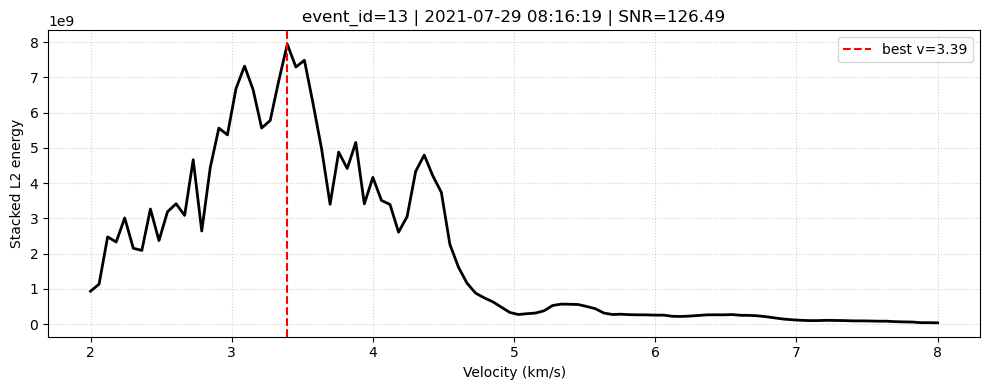

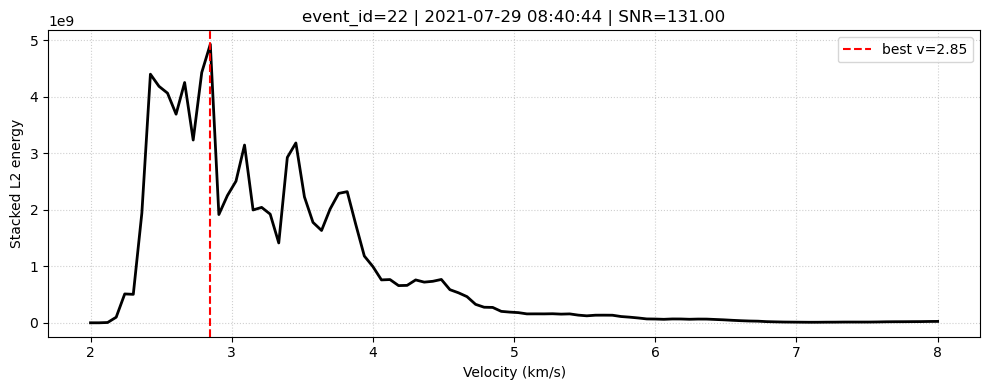

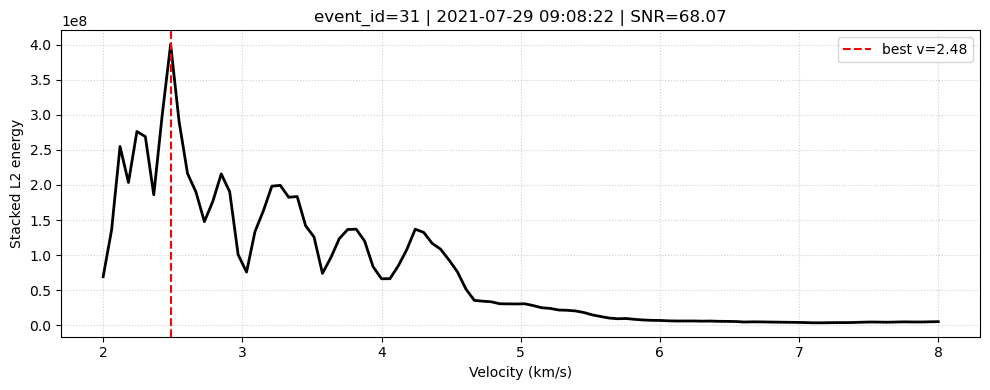

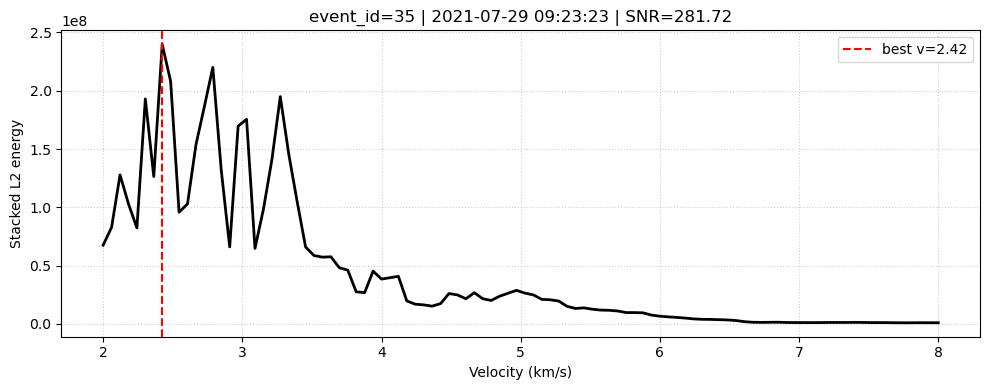

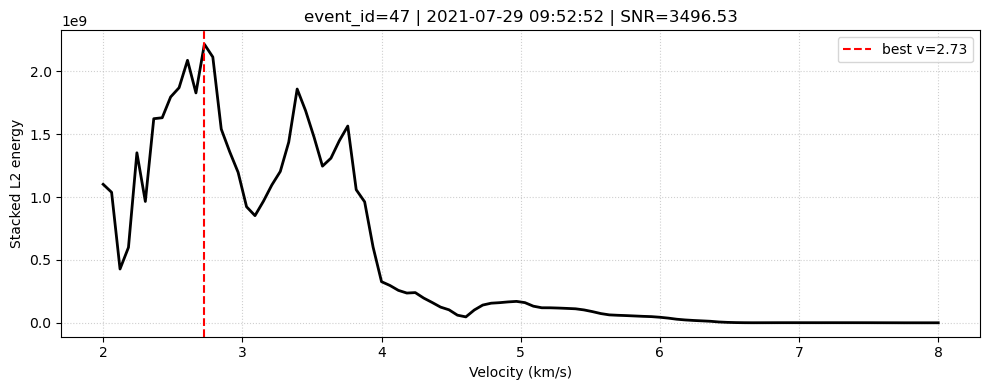

(PosixPath('/home/elizabeth/soft/src/QuickQuake/data/merged/output/GAMMA_qc_velocity.csv'),
    event_id                             time  best_v_km_s          snr  \
 0        13 2021-07-29 08:16:19.590000+00:00     3.393939   126.493444   
 1        22 2021-07-29 08:40:44.620000+00:00     2.848485   130.996477   
 2        31 2021-07-29 09:08:22.970000+00:00     2.484848    68.069631   
 3        35 2021-07-29 09:23:23.600000+00:00     2.424242   281.715660   
 4        47 2021-07-29 09:52:52.550000+00:00     2.727273  3496.529915   
 
    num_stations  n_files  
 0            11        2  
 1            11        2  
 2            10        2  
 3            10        2  
 4            10        2  )

In [1]:
# ============================================================
# QQ_qc_velocity — Notebook version (IDENTICAL to the script)
# ============================================================

from pathlib import Path
from typing import Dict, Tuple, Optional, List
import re
from datetime import datetime
from bisect import bisect_right

import numpy as np
import pandas as pd
import obspy
from obspy import read, UTCDateTime
from obspy.geodetics.base import gps2dist_azimuth

# ----------------------------
# USER SETTINGS (edit these)
# ----------------------------
DATA_ROOT = Path("/home/elizabeth/soft/src/QuickQuake/data")  # same root that contains chunk dirs + merged/
NAMEBASE  = "GAMMA"

# parameters (same defaults as script)
PRE_S   = 10.0
POST_S  = 40.0
FREQMIN = 1.0
FREQMAX = 5.0
VMIN    = 2.0
VMAX    = 8.0
VSTEPS  = 100
WINLEN  = 1.0

PAD_NEIGHBORS   = True
GEOM_CORRECTION = False
EPS             = 1e-12

MAKE_PLOT = True          # True to plot per event
MAX_EVENTS = 5             # 0 = all


CHUNK_RE = re.compile(r"^\d{8}T\d{6}$")  # YYYYmmddTHHMMSS


# ----------------------------
# Chunk index (IDENTICAL)
# ----------------------------
def build_chunk_index(data_root: Path):
    chunks = []
    for p in data_root.iterdir():
        if p.is_dir() and CHUNK_RE.match(p.name):
            dt = datetime.strptime(p.name, "%Y%m%dT%H%M%S")
            chunks.append((UTCDateTime(dt), p))
    chunks.sort(key=lambda x: x[0])
    if not chunks:
        raise RuntimeError(f"No chunk folders found in {data_root}")
    return [t for t, _ in chunks], [d for _, d in chunks]


def chunk_idx_for_time(t: UTCDateTime, times: List[UTCDateTime]) -> int:
    i = bisect_right(times, t) - 1
    return 0 if i < 0 else (len(times) - 1 if i >= len(times) else i)


def chunk_dirs_for_window(
    t_start: UTCDateTime,
    t_end: UTCDateTime,
    times: List[UTCDateTime],
    dirs: List[Path],
    pad_neighbors: bool = True
) -> List[Path]:
    i0 = chunk_idx_for_time(t_start, times)
    i1 = chunk_idx_for_time(t_end,   times)
    a, b = i0, i1
    if pad_neighbors:
        a = max(0, a - 1)
        b = min(len(dirs) - 1, b + 1)
    return dirs[a:b+1]


def waveform_files_for_window(
    t_start: UTCDateTime,
    t_end: UTCDateTime,
    times: List[UTCDateTime],
    dirs: List[Path],
    pad_neighbors: bool = True
) -> List[Path]:
    chunk_dirs = chunk_dirs_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
    files, seen = [], set()
    for cd in chunk_dirs:
        wdir = cd / "waveforms"
        if not wdir.exists():
            continue
        for fp in sorted(wdir.glob("*.mseed")):
            if fp not in seen:
                seen.add(fp)
                files.append(fp)
    return files


# ----------------------------
# Stream cache (IDENTICAL)
# ----------------------------
class StreamCache:
    def __init__(self):
        self._key = None
        self._st = None

    def get_stream(
        self,
        t_start: UTCDateTime,
        t_end: UTCDateTime,
        times: List[UTCDateTime],
        dirs: List[Path],
        pad_neighbors: bool = True
    ):
        files = waveform_files_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
        if not files:
            return None, []

        key = tuple(str(f) for f in files)
        if self._key == key and self._st is not None:
            return self._st, list(files)

        st = None
        for fp in files:
            try:
                s = read(str(fp))
                st = s if st is None else (st + s)
            except Exception:
                # quiet by default
                pass

        if st is None:
            self._key = None
            self._st = None
            return None, list(files)

        st.merge(fill_value="interpolate")
        self._key = key
        self._st = st
        return st, list(files)


# ----------------------------
# Helpers (IDENTICAL)
# ----------------------------
def stations_by_hypo_distance_km(stations: pd.DataFrame, ev_lat: float, ev_lon: float, ev_depth_km: float):
    hypo_km = []
    for _, r in stations.iterrows():
        d_m, _, _ = gps2dist_azimuth(ev_lat, ev_lon, float(r["lat"]), float(r["lon"]))
        horiz_km = d_m / 1000.0
        vert_km  = float(ev_depth_km) + float(r.get("elev_km", 0.0))
        hypo_km.append(float(np.hypot(horiz_km, vert_km)))

    tmp = stations.copy()
    tmp["hypo_km"] = hypo_km
    tmp = tmp.sort_values("hypo_km")
    return dict(zip(tmp["id"], tmp["hypo_km"]))


def best_Z_channel_for_station(st: obspy.Stream, net_sta: str) -> Optional[str]:
    prefs = ["BHZ", "EHZ", "SHZ", "HHZ"]
    chans = {tr.stats.channel for tr in st
             if f"{tr.stats.network}.{tr.stats.station}" == net_sta}
    for c in prefs:
        if c in chans:
            return c
    return None


def window_l2_energy_fast(tr: obspy.Trace, t_abs: UTCDateTime, win_len_s: float) -> float:
    sr = float(tr.stats.sampling_rate)
    n = tr.data.size
    if n == 0 or not np.isfinite(sr) or sr <= 0:
        return 0.0

    half = 0.5 * float(win_len_s)
    t0_win = t_abs - half

    i0 = int((t0_win - tr.stats.starttime) * sr)
    nsamp = int(max(1, round(float(win_len_s) * sr)))
    i1 = i0 + nsamp

    a = max(i0, 0)
    b = min(i1, n)
    if b <= a:
        return 0.0

    x = tr.data[a:b].astype(np.float64, copy=False)
    return float(np.dot(x, x))


# ----------------------------
# Paths resolution + input loading (IDENTICAL logic)
# ----------------------------
def resolve_paths(data_root: Path, namebase: str):
    merged_in = data_root / "merged" / "input"
    merged_out = data_root / "merged" / "output"

    picks_csv = merged_in / f"{namebase}_picks_cleaned.csv"
    stations_json = merged_in / f"{namebase}_station_list.json"

    catalog_candidates = [
        merged_out / f"{namebase}_hypodd_catalog.csv",
        merged_out / f"{namebase}_catalog.csv",
        merged_out / f"{namebase}_gamma_catalog.csv",
    ]
    catalog_csv = None
    for c in catalog_candidates:
        if c.exists():
            catalog_csv = c
            break
    if catalog_csv is None:
        raise FileNotFoundError(f"No catalog found. Tried: {[str(x) for x in catalog_candidates]}")

    out_csv = merged_out / f"{namebase}_qc_velocity.csv"
    return catalog_csv, picks_csv, stations_json, out_csv


def load_inputs(catalog_csv: Path, picks_csv: Path, stations_json: Path):
    catalog = pd.read_csv(catalog_csv)
    picks = pd.read_csv(picks_csv)

    catalog["time"] = pd.to_datetime(catalog["time"], utc=True, errors="coerce")
    picks["timestamp"] = pd.to_datetime(picks["timestamp"], utc=True, errors="coerce")

    catalog = catalog.dropna(subset=["time"]).reset_index(drop=True)
    picks = picks.dropna(subset=["timestamp"]).reset_index(drop=True)

    catalog["event_id"] = pd.to_numeric(catalog["event_id"], errors="coerce")
    picks["event_id_mapped"] = pd.to_numeric(picks["event_id_mapped"], errors="coerce")

    catalog = catalog.dropna(subset=["event_id"]).reset_index(drop=True)
    picks = picks.dropna(subset=["event_id_mapped"]).reset_index(drop=True)

    station_df = pd.read_json(stations_json).T
    station_df.index.name = "id"
    station_df["id"] = station_df.index.astype(str)
    station_df["elev_km"] = station_df.get("elevation(m)", 0.0).astype(float) / 1000.0

    stations = (
        station_df.rename(columns={"latitude": "lat", "longitude": "lon"})
        .reset_index(drop=True)[["id", "lat", "lon", "elev_km"]]
        .dropna(subset=["lat", "lon"])
        .drop_duplicates(subset=["id"])
        .reset_index(drop=True)
    )

    return catalog, picks, stations


# ----------------------------
# QC core (single event) — IDENTICAL
# ----------------------------
def qc_one_event(
    row_event: pd.Series,
    picks_clean: pd.DataFrame,
    stations: pd.DataFrame,
    times: List[UTCDateTime],
    dirs: List[Path],
    cache: StreamCache,
    pre_s: float,
    post_s: float,
    freqmin: float,
    freqmax: float,
    vmin: float,
    vmax: float,
    vsteps: int,
    winlen: float,
    pad_neighbors: bool,
    geom_correction: bool,
    eps: float,
    make_plot: bool,
):
    t0 = UTCDateTime(row_event["time"].to_pydatetime())
    ev_lat = float(row_event["latitude"])
    ev_lon = float(row_event["longitude"])
    ev_depth_km = float(row_event.get("depth_km", 0.0))
    eid = int(row_event["event_id"])

    t_start = t0 - float(pre_s)
    t_end   = t0 + float(post_s)

    ev_picks = picks_clean[picks_clean["event_id_mapped"] == eid]
    if ev_picks.empty:
        return None

    stations_with_picks = ev_picks["id"].unique().tolist()
    if len(stations_with_picks) < 4:
        return None

    dist_map_all = stations_by_hypo_distance_km(stations, ev_lat, ev_lon, ev_depth_km)
    dist_map = {sid: dist_map_all[sid] for sid in stations_with_picks if sid in dist_map_all}
    if len(dist_map) < 4:
        return None

    st_raw, files = cache.get_stream(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
    if st_raw is None:
        return None

    prepped: Dict[str, Tuple[obspy.Trace, float]] = {}

    for sid, dkm in dist_map.items():
        net, sta = sid.split(".")[0], sid.split(".")[1]
        chz = best_Z_channel_for_station(st_raw, f"{net}.{sta}")
        if chz is None:
            continue

        tr_list = st_raw.select(network=net, station=sta, channel=chz)
        if not tr_list:
            continue

        tr = tr_list[0].copy()
        tr.trim(t_start, t_end, pad=True, fill_value=0)  # <- CRITICAL: identical

        tr.detrend("demean")
        tr.taper(max_percentage=0.05, type="cosine")

        sr = float(tr.stats.sampling_rate)
        nyq = 0.5 * sr
        fmin = max(0.001, min(float(freqmin), nyq * 0.99))
        fmax = max(fmin + 0.001, min(float(freqmax), nyq * 0.99))
        if fmax > fmin:
            tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

        prepped[sid] = (tr, float(dkm))

    if len(prepped) < 4:
        return None

    v_grid = np.flip(np.linspace(float(vmin), float(vmax), int(vsteps)))
    energies = np.zeros_like(v_grid, dtype=np.float64)

    for i, v_test in enumerate(v_grid):
        Ev = 0.0
        inv_v = 1.0 / max(float(v_test), 1e-6)
        for _, (tr, dkm) in prepped.items():
            t_abs = t0 + (dkm * inv_v)
            E = window_l2_energy_fast(tr, t_abs, win_len_s=float(winlen))
            if geom_correction:
                E *= (dkm ** 2)
            Ev += E
        energies[i] = Ev

    if not np.any(np.isfinite(energies)) or float(np.nanmax(energies)) <= 0.0:
        return None

    v_grid_noise = np.flip(np.linspace(10.0, 12.0, 20))
    energies_noise = np.zeros_like(v_grid_noise, dtype=np.float64)
    for i, v_test in enumerate(v_grid_noise):
        Ev = 0.0
        inv_v = 1.0 / max(float(v_test), 1e-6)
        for _, (tr, dkm) in prepped.items():
            t_abs = t0 + (dkm * inv_v)
            Ev += window_l2_energy_fast(tr, t_abs, win_len_s=float(winlen))
        energies_noise[i] = Ev

    i_peak = int(np.nanargmax(energies))
    best_v = float(v_grid[i_peak])
    peak   = float(energies[i_peak])
    baseline = float(np.median(energies_noise))
    snr = peak / (baseline + float(eps))

    if make_plot:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(v_grid, energies, "k-", lw=2)
        ax.axvline(best_v, color="red", ls="--", lw=1.5, label=f"best v={best_v:.2f}")
        ax.set_title(f"event_id={eid} | {t0.strftime('%Y-%m-%d %H:%M:%S')} | SNR={snr:.2f}")
        ax.set_xlabel("Velocity (km/s)")
        ax.set_ylabel("Stacked L2 energy")
        ax.grid(ls=":", alpha=0.6)
        ax.legend()
        plt.tight_layout()
        plt.show()

    return {
        "event_id": eid,
        "time": row_event["time"],
        "best_v_km_s": best_v,
        "snr": snr,
        "num_stations": len(prepped),
        "n_files": len(files),
    }


# ----------------------------
# RUNNER (same as script main, but notebook-style)
# ----------------------------
catalog_csv, picks_csv, stations_json, out_csv_default = resolve_paths(DATA_ROOT, NAMEBASE)
catalog, picks_clean, stations = load_inputs(catalog_csv, picks_csv, stations_json)

times, dirs = build_chunk_index(DATA_ROOT)

# sort events by time (helps cache hit rate) — identical
catalog = catalog.sort_values("time").reset_index(drop=True)

cache = StreamCache()

rows = []
n_total = len(catalog) if MAX_EVENTS <= 0 else min(len(catalog), MAX_EVENTS)

for i in range(n_total):
    row_event = catalog.iloc[i]
    r = qc_one_event(
        row_event=row_event,
        picks_clean=picks_clean,
        stations=stations,
        times=times,
        dirs=dirs,
        cache=cache,
        pre_s=PRE_S,
        post_s=POST_S,
        freqmin=FREQMIN,
        freqmax=FREQMAX,
        vmin=VMIN,
        vmax=VMAX,
        vsteps=VSTEPS,
        winlen=WINLEN,
        pad_neighbors=PAD_NEIGHBORS,
        geom_correction=GEOM_CORRECTION,
        eps=EPS,
        make_plot=MAKE_PLOT,
    )
    if r is not None:
        rows.append(r)

out_df = pd.DataFrame(rows)
out_csv = out_csv_default
out_df.to_csv(out_csv, index=False)

out_csv, out_df.head(30)


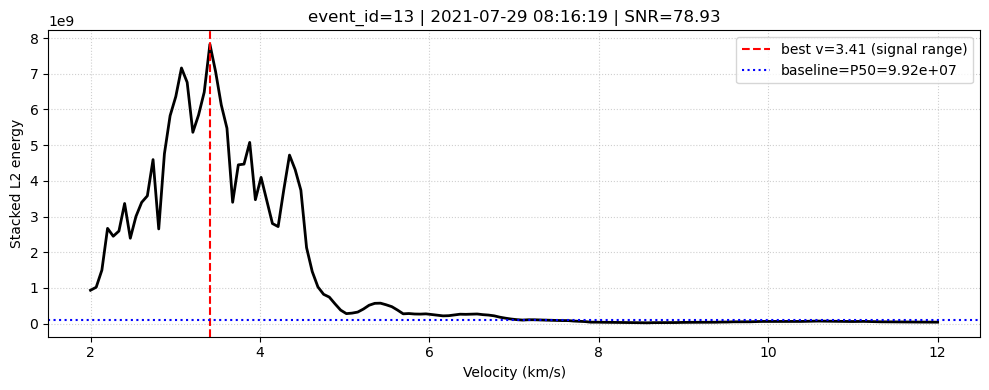

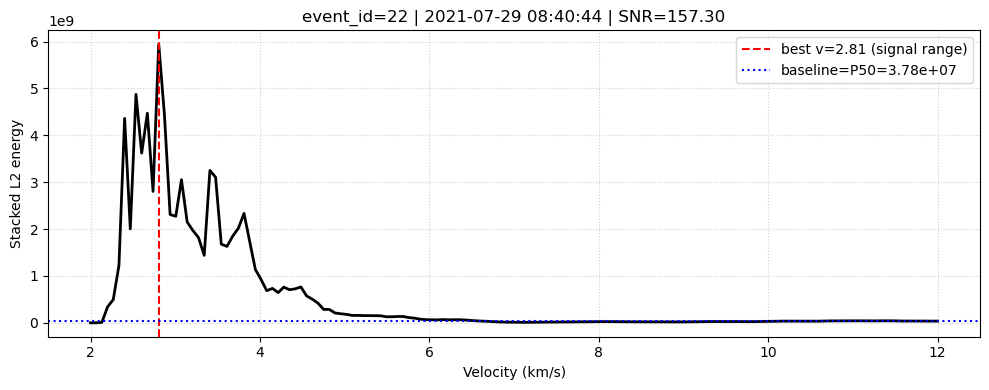

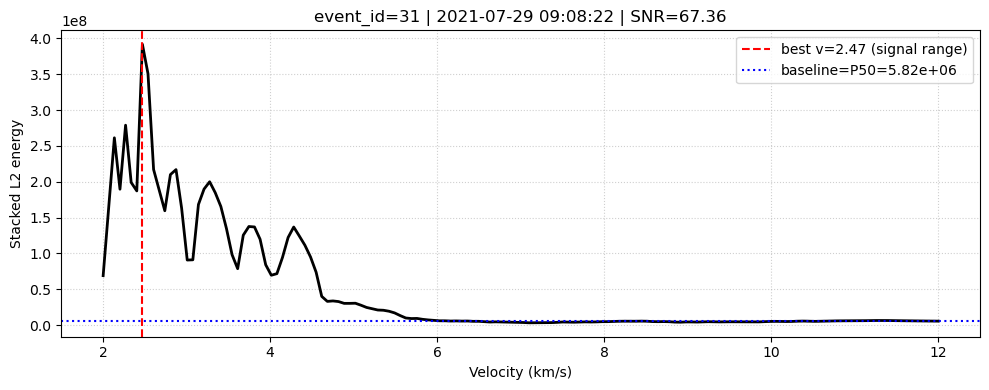

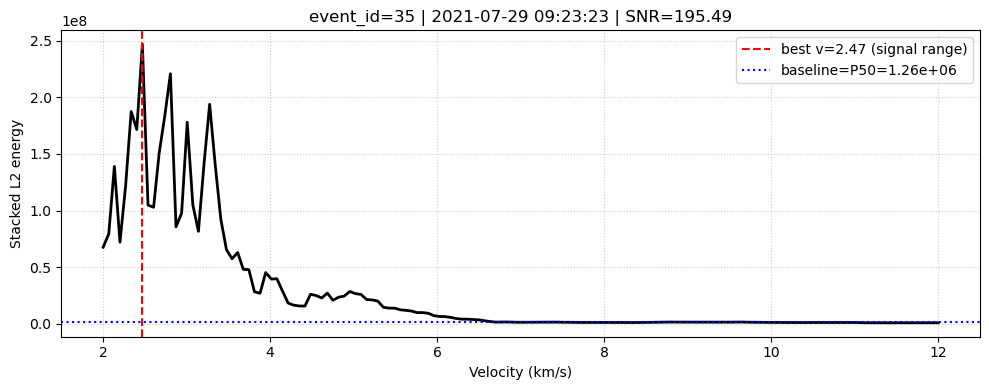

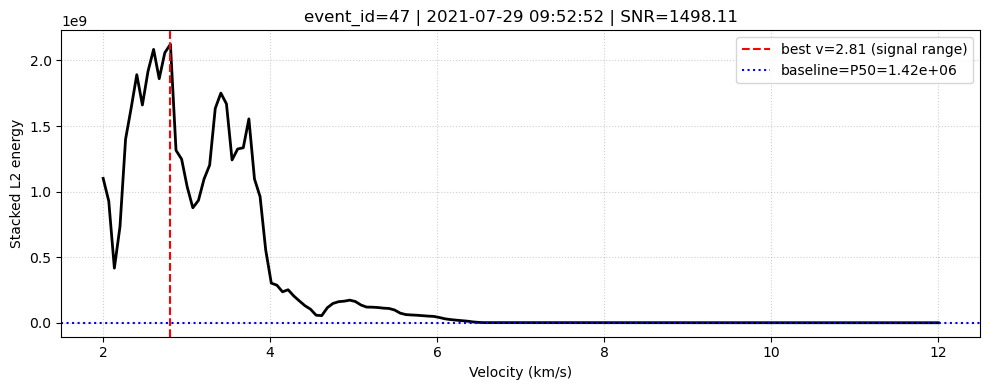

(PosixPath('/home/elizabeth/soft/src/QuickQuake/data/merged/output/GAMMA_qc_velocity_PCTL_NOISE.csv'),
    event_id                             time  best_v_km_s          snr  \
 0        13 2021-07-29 08:16:19.590000+00:00     3.409396    78.932882   
 1        22 2021-07-29 08:40:44.620000+00:00     2.805369   157.302591   
 2        31 2021-07-29 09:08:22.970000+00:00     2.469799    67.362126   
 3        35 2021-07-29 09:23:23.600000+00:00     2.469799   195.487486   
 4        47 2021-07-29 09:52:52.550000+00:00     2.805369  1498.111983   
 
    baseline_energy  noise_percentile  num_stations  n_files  
 0     9.915344e+07              50.0            11        2  
 1     3.777025e+07              50.0            11        2  
 2     5.816753e+06              50.0            10        2  
 3     1.263871e+06              50.0            10        2  
 4     1.417353e+06              50.0            10        2  )

In [2]:
# ============================================================
# QQ_qc_velocity — Notebook version (percentile-noise from curve)
#   Simplified: ONLY curve_percentile baseline
#   Peak-exclusion band is FIXED internally (0.4 km/s)
# ============================================================

from pathlib import Path
from typing import Dict, Tuple, Optional, List
import re
from datetime import datetime
from bisect import bisect_right

import numpy as np
import pandas as pd
import obspy
from obspy import read, UTCDateTime
from obspy.geodetics.base import gps2dist_azimuth


# ----------------------------
# USER SETTINGS (edit these)
# ----------------------------
DATA_ROOT = Path("/home/elizabeth/soft/src/QuickQuake/data")  # contains chunk dirs + merged/
NAMEBASE  = "GAMMA"

# Time window around origin time used to load/trim traces
PRE_S   = 10.0
POST_S  = 40.0

# Filter
FREQMIN = 1.0
FREQMAX = 5.0

# --- Signal search range (where we pick best_v) ---
VMIN_SIGNAL = 2.0
VMAX_SIGNAL = 8.0

# --- Curve computation range (used for baseline/noise too) ---
# include high velocities here (as your prof suggested)
VMIN_CURVE   = 2.0
VMAX_CURVE   = 12.0
VSTEPS_CURVE = 150  # density of curve samples

WINLEN  = 1.0  # seconds

PAD_NEIGHBORS   = True
GEOM_CORRECTION = False
EPS             = 1e-12

MAKE_PLOT  = True
MAX_EVENTS = 5   # 0 = all

# --- Noise baseline from curve: percentile ONLY ---
NOISE_PERCENTILE = 50.0   # e.g., 40 or 50

CHUNK_RE = re.compile(r"^\d{8}T\d{6}$")  # YYYYmmddTHHMMSS


# ----------------------------
# Chunk index
# ----------------------------
def build_chunk_index(data_root: Path):
    chunks = []
    for p in data_root.iterdir():
        if p.is_dir() and CHUNK_RE.match(p.name):
            dt = datetime.strptime(p.name, "%Y%m%dT%H%M%S")
            chunks.append((UTCDateTime(dt), p))
    chunks.sort(key=lambda x: x[0])
    if not chunks:
        raise RuntimeError(f"No chunk folders found in {data_root}")
    return [t for t, _ in chunks], [d for _, d in chunks]


def chunk_idx_for_time(t: UTCDateTime, times: List[UTCDateTime]) -> int:
    i = bisect_right(times, t) - 1
    return 0 if i < 0 else (len(times) - 1 if i >= len(times) else i)


def chunk_dirs_for_window(
    t_start: UTCDateTime,
    t_end: UTCDateTime,
    times: List[UTCDateTime],
    dirs: List[Path],
    pad_neighbors: bool = True
) -> List[Path]:
    i0 = chunk_idx_for_time(t_start, times)
    i1 = chunk_idx_for_time(t_end,   times)
    a, b = i0, i1
    if pad_neighbors:
        a = max(0, a - 1)
        b = min(len(dirs) - 1, b + 1)
    return dirs[a:b+1]


def waveform_files_for_window(
    t_start: UTCDateTime,
    t_end: UTCDateTime,
    times: List[UTCDateTime],
    dirs: List[Path],
    pad_neighbors: bool = True
) -> List[Path]:
    chunk_dirs = chunk_dirs_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
    files, seen = [], set()
    for cd in chunk_dirs:
        wdir = cd / "waveforms"
        if not wdir.exists():
            continue
        for fp in sorted(wdir.glob("*.mseed")):
            if fp not in seen:
                seen.add(fp)
                files.append(fp)
    return files


# ----------------------------
# Stream cache
# ----------------------------
class StreamCache:
    def __init__(self):
        self._key = None
        self._st = None

    def get_stream(
        self,
        t_start: UTCDateTime,
        t_end: UTCDateTime,
        times: List[UTCDateTime],
        dirs: List[Path],
        pad_neighbors: bool = True
    ):
        files = waveform_files_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
        if not files:
            return None, []

        key = tuple(str(f) for f in files)
        if self._key == key and self._st is not None:
            return self._st, list(files)

        st = None
        for fp in files:
            try:
                s = read(str(fp))
                st = s if st is None else (st + s)
            except Exception:
                pass

        if st is None:
            self._key = None
            self._st = None
            return None, list(files)

        st.merge(fill_value="interpolate")
        self._key = key
        self._st = st
        return st, list(files)


# ----------------------------
# Helpers
# ----------------------------
def stations_by_hypo_distance_km(stations: pd.DataFrame, ev_lat: float, ev_lon: float, ev_depth_km: float):
    hypo_km = []
    for _, r in stations.iterrows():
        d_m, _, _ = gps2dist_azimuth(ev_lat, ev_lon, float(r["lat"]), float(r["lon"]))
        horiz_km = d_m / 1000.0
        vert_km  = float(ev_depth_km) + float(r.get("elev_km", 0.0))
        hypo_km.append(float(np.hypot(horiz_km, vert_km)))

    tmp = stations.copy()
    tmp["hypo_km"] = hypo_km
    tmp = tmp.sort_values("hypo_km")
    return dict(zip(tmp["id"], tmp["hypo_km"]))


def best_Z_channel_for_station(st: obspy.Stream, net_sta: str) -> Optional[str]:
    prefs = ["BHZ", "EHZ", "SHZ", "HHZ"]
    chans = {tr.stats.channel for tr in st
             if f"{tr.stats.network}.{tr.stats.station}" == net_sta}
    for c in prefs:
        if c in chans:
            return c
    return None


def window_l2_energy_fast(tr: obspy.Trace, t_abs: UTCDateTime, win_len_s: float) -> float:
    sr = float(tr.stats.sampling_rate)
    n = tr.data.size
    if n == 0 or not np.isfinite(sr) or sr <= 0:
        return 0.0

    half = 0.5 * float(win_len_s)
    t0_win = t_abs - half

    i0 = int((t0_win - tr.stats.starttime) * sr)
    nsamp = int(max(1, round(float(win_len_s) * sr)))
    i1 = i0 + nsamp

    a = max(i0, 0)
    b = min(i1, n)
    if b <= a:
        return 0.0

    x = tr.data[a:b].astype(np.float64, copy=False)
    return float(np.dot(x, x))


def baseline_percentile_from_curve(
    v_grid: np.ndarray,
    energies: np.ndarray,
    best_v: float,
    percentile: float
) -> float:
    # FIXED: exclude ±0.4 km/s around peak so signal doesn't inflate "noise"
    EXCLUDE_BAND = 0.4

    mask = np.isfinite(energies)
    mask &= (np.abs(v_grid - float(best_v)) > EXCLUDE_BAND)

    e = energies[mask]
    if e.size == 0:
        return float("nan")

    return float(np.percentile(e, float(percentile)))


# ----------------------------
# Paths resolution + input loading
# ----------------------------
def resolve_paths(data_root: Path, namebase: str):
    merged_in = data_root / "merged" / "input"
    merged_out = data_root / "merged" / "output"

    picks_csv = merged_in / f"{namebase}_picks_cleaned.csv"
    stations_json = merged_in / f"{namebase}_station_list.json"

    catalog_candidates = [
        merged_out / f"{namebase}_hypodd_catalog.csv",
        merged_out / f"{namebase}_catalog.csv",
        merged_out / f"{namebase}_gamma_catalog.csv",
    ]
    catalog_csv = None
    for c in catalog_candidates:
        if c.exists():
            catalog_csv = c
            break
    if catalog_csv is None:
        raise FileNotFoundError(f"No catalog found. Tried: {[str(x) for x in catalog_candidates]}")

    out_csv = merged_out / f"{namebase}_qc_velocity.csv"
    return catalog_csv, picks_csv, stations_json, out_csv


def load_inputs(catalog_csv: Path, picks_csv: Path, stations_json: Path):
    catalog = pd.read_csv(catalog_csv)
    picks = pd.read_csv(picks_csv)

    catalog["time"] = pd.to_datetime(catalog["time"], utc=True, errors="coerce")
    picks["timestamp"] = pd.to_datetime(picks["timestamp"], utc=True, errors="coerce")

    catalog = catalog.dropna(subset=["time"]).reset_index(drop=True)
    picks = picks.dropna(subset=["timestamp"]).reset_index(drop=True)

    catalog["event_id"] = pd.to_numeric(catalog["event_id"], errors="coerce")
    picks["event_id_mapped"] = pd.to_numeric(picks["event_id_mapped"], errors="coerce")

    catalog = catalog.dropna(subset=["event_id"]).reset_index(drop=True)
    picks = picks.dropna(subset=["event_id_mapped"]).reset_index(drop=True)

    station_df = pd.read_json(stations_json).T
    station_df.index.name = "id"
    station_df["id"] = station_df.index.astype(str)
    station_df["elev_km"] = station_df.get("elevation(m)", 0.0).astype(float) / 1000.0

    stations = (
        station_df.rename(columns={"latitude": "lat", "longitude": "lon"})
        .reset_index(drop=True)[["id", "lat", "lon", "elev_km"]]
        .dropna(subset=["lat", "lon"])
        .drop_duplicates(subset=["id"])
        .reset_index(drop=True)
    )

    return catalog, picks, stations


# ----------------------------
# QC core (single event)
# ----------------------------
def qc_one_event(
    row_event: pd.Series,
    picks_clean: pd.DataFrame,
    stations: pd.DataFrame,
    times: List[UTCDateTime],
    dirs: List[Path],
    cache: StreamCache,
    pre_s: float,
    post_s: float,
    freqmin: float,
    freqmax: float,
    vmin_signal: float,
    vmax_signal: float,
    vmin_curve: float,
    vmax_curve: float,
    vsteps_curve: int,
    winlen: float,
    pad_neighbors: bool,
    geom_correction: bool,
    eps: float,
    make_plot: bool,
):
    t0 = UTCDateTime(row_event["time"].to_pydatetime())
    ev_lat = float(row_event["latitude"])
    ev_lon = float(row_event["longitude"])
    ev_depth_km = float(row_event.get("depth_km", 0.0))
    eid = int(row_event["event_id"])

    t_start = t0 - float(pre_s)
    t_end   = t0 + float(post_s)

    ev_picks = picks_clean[picks_clean["event_id_mapped"] == eid]
    if ev_picks.empty:
        return None

    stations_with_picks = ev_picks["id"].unique().tolist()
    if len(stations_with_picks) < 4:
        return None

    dist_map_all = stations_by_hypo_distance_km(stations, ev_lat, ev_lon, ev_depth_km)
    dist_map = {sid: dist_map_all[sid] for sid in stations_with_picks if sid in dist_map_all}
    if len(dist_map) < 4:
        return None

    st_raw, files = cache.get_stream(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
    if st_raw is None:
        return None

    prepped: Dict[str, Tuple[obspy.Trace, float]] = {}
    for sid, dkm in dist_map.items():
        net, sta = sid.split(".")[0], sid.split(".")[1]
        chz = best_Z_channel_for_station(st_raw, f"{net}.{sta}")
        if chz is None:
            continue

        tr_list = st_raw.select(network=net, station=sta, channel=chz)
        if not tr_list:
            continue

        tr = tr_list[0].copy()
        tr.trim(t_start, t_end, pad=True, fill_value=0)

        tr.detrend("demean")
        tr.taper(max_percentage=0.05, type="cosine")

        sr = float(tr.stats.sampling_rate)
        nyq = 0.5 * sr
        fmin = max(0.001, min(float(freqmin), nyq * 0.99))
        fmax = max(fmin + 0.001, min(float(freqmax), nyq * 0.99))
        if fmax > fmin:
            tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

        prepped[sid] = (tr, float(dkm))

    if len(prepped) < 4:
        return None

    # --- ONE curve including high-v range ---
    v_grid = np.flip(np.linspace(float(vmin_curve), float(vmax_curve), int(vsteps_curve)))
    energies = np.zeros_like(v_grid, dtype=np.float64)

    for i, v_test in enumerate(v_grid):
        Ev = 0.0
        inv_v = 1.0 / max(float(v_test), 1e-6)
        for _, (tr, dkm) in prepped.items():
            t_abs = t0 + (dkm * inv_v)
            E = window_l2_energy_fast(tr, t_abs, win_len_s=float(winlen))
            if geom_correction:
                E *= (dkm ** 2)
            Ev += E
        energies[i] = Ev

    if not np.any(np.isfinite(energies)) or float(np.nanmax(energies)) <= 0.0:
        return None

    # --- Pick signal peak ONLY within [VMIN_SIGNAL, VMAX_SIGNAL] ---
    sig_mask = (v_grid >= float(vmin_signal)) & (v_grid <= float(vmax_signal)) & np.isfinite(energies)
    if not np.any(sig_mask):
        return None

    i_peak_local = int(np.nanargmax(np.where(sig_mask, energies, -np.inf)))
    best_v = float(v_grid[i_peak_local])
    peak   = float(energies[i_peak_local])

    # --- Baseline: percentile of curve (peak band excluded internally) ---
    baseline = baseline_percentile_from_curve(
        v_grid=v_grid,
        energies=energies,
        best_v=best_v,
        percentile=NOISE_PERCENTILE
    )
    if not np.isfinite(baseline):
        return None

    snr = peak / (baseline + float(eps))

    if make_plot:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(v_grid, energies, "k-", lw=2)
        ax.axvline(best_v, color="red", ls="--", lw=1.5, label=f"best v={best_v:.2f} (signal range)")
        ax.axhline(baseline, color="blue", ls=":", lw=1.5, label=f"baseline=P{NOISE_PERCENTILE:.0f}={baseline:.2e}")
        ax.set_title(f"event_id={eid} | {t0.strftime('%Y-%m-%d %H:%M:%S')} | SNR={snr:.2f}")
        ax.set_xlabel("Velocity (km/s)")
        ax.set_ylabel("Stacked L2 energy")
        ax.grid(ls=":", alpha=0.6)
        ax.legend()
        plt.tight_layout()
        plt.show()

    return {
        "event_id": eid,
        "time": row_event["time"],
        "best_v_km_s": best_v,
        "snr": snr,
        "baseline_energy": baseline,
        "noise_percentile": float(NOISE_PERCENTILE),
        "num_stations": len(prepped),
        "n_files": len(files),
    }


# ----------------------------
# RUNNER (notebook-style)
# ----------------------------
catalog_csv, picks_csv, stations_json, out_csv_default = resolve_paths(DATA_ROOT, NAMEBASE)
catalog, picks_clean, stations = load_inputs(catalog_csv, picks_csv, stations_json)

times, dirs = build_chunk_index(DATA_ROOT)

# sort events by time (helps cache hit rate)
catalog = catalog.sort_values("time").reset_index(drop=True)

cache = StreamCache()

rows = []
n_total = len(catalog) if MAX_EVENTS <= 0 else min(len(catalog), MAX_EVENTS)

for i in range(n_total):
    row_event = catalog.iloc[i]
    r = qc_one_event(
        row_event=row_event,
        picks_clean=picks_clean,
        stations=stations,
        times=times,
        dirs=dirs,
        cache=cache,
        pre_s=PRE_S,
        post_s=POST_S,
        freqmin=FREQMIN,
        freqmax=FREQMAX,
        vmin_signal=VMIN_SIGNAL,
        vmax_signal=VMAX_SIGNAL,
        vmin_curve=VMIN_CURVE,
        vmax_curve=VMAX_CURVE,
        vsteps_curve=VSTEPS_CURVE,
        winlen=WINLEN,
        pad_neighbors=PAD_NEIGHBORS,
        geom_correction=GEOM_CORRECTION,
        eps=EPS,
        make_plot=MAKE_PLOT,
    )
    if r is not None:
        rows.append(r)

out_df = pd.DataFrame(rows)
out_csv = out_csv_default.with_name(out_csv_default.stem + "_PCTL_NOISE.csv")
out_df.to_csv(out_csv, index=False)

out_csv, out_df.head(30)
